In [1]:
# ==============================================================================
# UNIFIED COCOA DISEASE DEEP LEARNING PIPELINE FOR EXTREME CLASS IMBALANCE
# ==============================================================================

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

In [2]:
# ------------------------------------------------------------------------------
# 1. PATH CONFIGURATION & USER DATA SETTINGS
# ------------------------------------------------------------------------------
# Set your local dataset folder directories here
TRAIN_DIR = r"D:\AnacondaNotebooks\Notebooks\CocoaDiseaseClassification\dataset\train"
VAL_DIR = r"D:\AnacondaNotebooks\Notebooks\CocoaDiseaseClassification\dataset\val"

IMG_SIZE = (224, 224)  # Native resolution requirement for EfficientNetV2B0 input dimensions
BATCH_SIZE = 32        # Balanced batch size to maintain gradient update stability on GPUs

In [3]:
# ------------------------------------------------------------------------------
# 2. ADVANCED DATA AUGMENTATION DATA GENERATORS
# ------------------------------------------------------------------------------
# In-memory geometric transformations prevent the model from memorizing rare class examples.
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # Normalizes image pixels natively for EfficientNet
    rotation_range=40,                       # Simulates different angles of field photography
    width_shift_range=0.2,                   # Handles varying positions of pods in camera frames
    height_shift_range=0.2,
    shear_range=0.2,                         # Simulates realistic physical perspectives and distortions
    zoom_range=0.2,                          # Models distance variations from the fruit surface
    horizontal_flip=True,                    # Doubles dataset variance without losing biological accuracy
    vertical_flip=True,                      # Accounts for arbitrary camera orientation in field conditions
    fill_mode='nearest'                      # Prevents blank border artifacts post-transformation
)

# Validation generator MUST strictly apply preprocessing only; no geometric shifting allowed.
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

print("[INFO] Initializing training image stream pipelines...")
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

print("\n[INFO] Initializing validation image stream pipelines...")
val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Must be False to preserve true index alignment for evaluation metrics
)

[INFO] Initializing training image stream pipelines...
Found 13855 images belonging to 6 classes.

[INFO] Initializing validation image stream pipelines...
Found 1729 images belonging to 6 classes.


In [4]:
# ------------------------------------------------------------------------------
# 3. LOGARITHMIC CAPPED CLASS WEIGHT COMPUTATION
# ------------------------------------------------------------------------------
# Smooths out extreme numerical disparities among minority samples to preserve structural learning.
train_labels = train_generator.classes
unique_classes = np.unique(train_labels)

# Compute traditional balanced weights first
raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=train_labels
)

# Apply a strategic logarithmic damping function to cap extreme penalties
# Formula applied: natural_log(raw_weight + 1) scaled by a preservation ceiling
class_weight_dict = {}
for cls, raw_w in zip(unique_classes, raw_weights):
    smoothed_w = np.log(raw_w + 1.0) * 3.5
    # Enforce a definitive safety boundary constraint to protect the majority class recall
    class_weight_dict[cls] = float(np.clip(smoothed_w, 1.0, 15.0))

print("\n[INFO] Computed Logarithmic Capped Class Weights:")
for idx, name in enumerate(train_generator.class_indices.keys()):
    print(f" -> {name.ljust(15)}: {class_weight_dict[idx]:.4f}")


[INFO] Computed Logarithmic Capped Class Weights:
 -> Anthracnose    : 2.8556
 -> CSSVD          : 2.2412
 -> Healthy        : 1.0000
 -> Monilia        : 8.3777
 -> Phytophthora   : 3.9249
 -> PodBorer       : 11.8049


In [5]:
# ------------------------------------------------------------------------------
# 4. MODEL DESIGN & TWO-STAGE ARCHITECTURE BUILD
# ------------------------------------------------------------------------------
print("\n[INFO] Constructing model architecture using EfficientNetV2B0 backbone...")
# Import core pretrained feature extraction layers configured with ImageNet weights
base_model = EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Phase A Layer Lock: Freeze base model to anchor foundational image processing features
base_model.trainable = False

# Construct a high-performance, regularized classification head
inputs = base_model.input
x = base_model.output
x = GlobalAveragePooling2D()(x)                       # Flattens 2D feature maps to dense vectors safely
x = BatchNormalization()(x)                           # Re-centers activations to accelerate training convergence
x = Dropout(0.4)(x)                                   # Strong regularizer to protect minority feature mappings
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=inputs, outputs=predictions)


[INFO] Constructing model architecture using EfficientNetV2B0 backbone...


In [6]:
# ------------------------------------------------------------------------------
# 5. PILOT TRAINING STABILIZATION PHASE
# ------------------------------------------------------------------------------
print("\n[INFO] Executing Phase A: Stabilization of custom top classification layers...")
model.compile(
    optimizer=Adam(learning_rate=1e-3), # Standard high learning rate for new weights
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Short run to ground random weights before opening base network blocks
model.fit(
    train_generator,
    epochs=4,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    verbose=1
)


[INFO] Executing Phase A: Stabilization of custom top classification layers...
Epoch 1/4
433/433 ━━━━━━━━━━━━━━━━━━━━ 524s 1s/step - accuracy: 0.6148 - loss: 2.0704 - val_accuracy: 0.7368 - val_loss: 0.6997
Epoch 2/4
433/433 ━━━━━━━━━━━━━━━━━━━━ 510s 1s/step - accuracy: 0.7105 - loss: 1.5411 - val_accuracy: 0.7600 - val_loss: 0.6160
Epoch 3/4
433/433 ━━━━━━━━━━━━━━━━━━━━ 495s 1s/step - accuracy: 0.7304 - loss: 1.3734 - val_accuracy: 0.7536 - val_loss: 0.6387
Epoch 4/4
433/433 ━━━━━━━━━━━━━━━━━━━━ 499s 1s/step - accuracy: 0.7381 - loss: 1.3423 - val_accuracy: 0.7068 - val_loss: 0.7170


In [7]:
# ------------------------------------------------------------------------------
# 6. DISCRIMINATIVE DEEP FINE-TUNING PHASE
# ------------------------------------------------------------------------------
print("\n[INFO] Executing Phase B: Unfreezing top 20 structural blocks for fine-tuning...")
base_model.trainable = True
# Freeze early layers to keep core primitive features (edges/textures) solid
for layer in base_model.layers[:-20]:
    if not isinstance(layer, BatchNormalization):
        layer.trainable = False

# Setup highly sensitive training monitoring tools to prevent overfitting
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint(filepath="max_efficiency_cocoa_model.keras", monitor='val_accuracy', save_best_only=True, verbose=1)
]

# Re-compile the network with a safe micro-learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5), # Prevent destroying foundational pre-trained weights
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n[INFO] Commencing fine-tuning optimization iterations...")
history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("\n[SUCCESS] Maximum efficiency single-cell training pipeline completed successfully!")


[INFO] Executing Phase B: Unfreezing top 20 structural blocks for fine-tuning...

[INFO] Commencing fine-tuning optimization iterations...
Epoch 1/25
433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6393 - loss: 2.5304
Epoch 1: val_accuracy improved from None to 0.67727, saving model to max_efficiency_cocoa_model.keras

Epoch 1: finished saving model to max_efficiency_cocoa_model.keras
433/433 ━━━━━━━━━━━━━━━━━━━━ 815s 2s/step - accuracy: 0.6480 - loss: 2.3843 - val_accuracy: 0.6773 - val_loss: 0.8694 - learning_rate: 1.0000e-05
Epoch 2/25
433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6464 - loss: 2.1528
Epoch 2: val_accuracy did not improve from 0.67727
433/433 ━━━━━━━━━━━━━━━━━━━━ 783s 2s/step - accuracy: 0.6523 - loss: 2.0884 - val_accuracy: 0.6767 - val_loss: 0.8466 - learning_rate: 1.0000e-05
Epoch 3/25
433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6511 - loss: 2.0418
Epoch 3: val_accuracy improved from 0.67727 to 0.68132, saving model to max_efficiency_cocoa

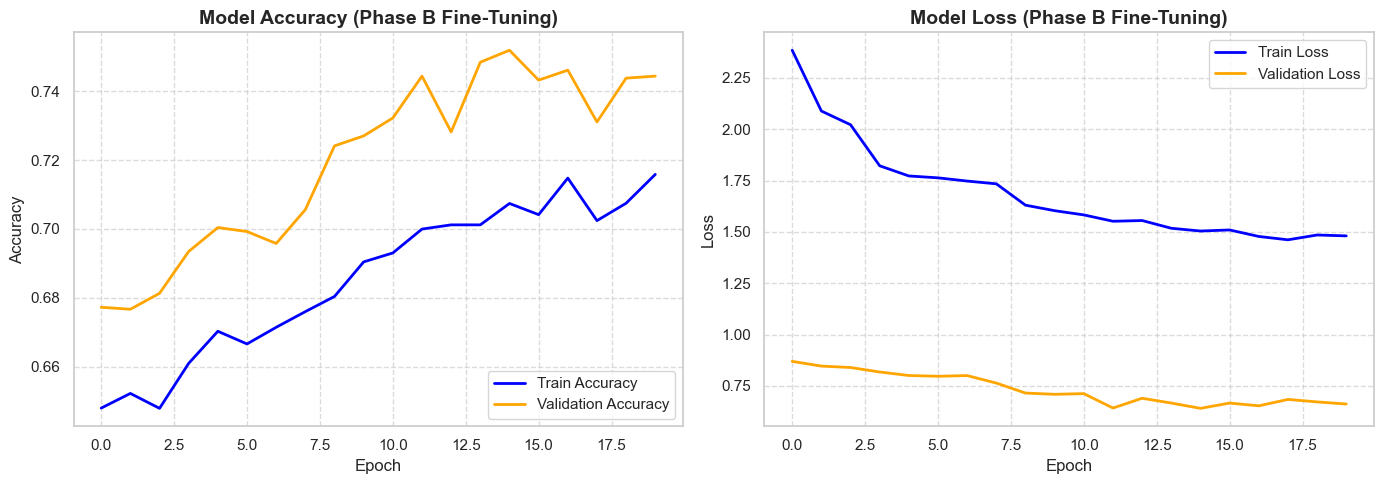

In [8]:
# ==============================================================================
# VISUALIZING TRAINING AND VALIDATION METRICS
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------------------------
# 1. ACCURACY PLOT
# ------------------------------------------------------------------------------
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
axes[0].set_title('Model Accuracy (Phase B Fine-Tuning)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.7)

# ------------------------------------------------------------------------------
# 2. LOSS PLOT
# ------------------------------------------------------------------------------
axes[1].plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
axes[1].set_title('Model Loss (Phase B Fine-Tuning)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.7)

# Adjust layout and display
plt.tight_layout()
plt.show()

In [ ]:
#https://plantvillage.psu.edu/topics/cocoa-cacao/infos     test images downoaded from this website